# Installation

In [1]:
!pip install tnreason==2.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 30.3 MB/s eta 0:00:00


#Basis encoding of the toy accounting system


We here decompose the basis encoding of the toy accounting system, using the syntactical reperesentation of the rules.

First accounting rule: Exactly one of the accounts is booked.
```
["xor", "A1", "A2"]
```
Second accounting rule: Feature implies account 1.
```
["imp", "F", "A1"]
```
Knowledge base of both rules:
```
["and", ["xor", "A1", "A2"], ["imp", "F", "A1"]]
```







## Representation by two formulas

In [4]:
from tnreason import engine, application
from tnreason.application import formulas_to_cores as ftc

def get_e1(color):
  return engine.create_from_slice_iterator(shape=[2], colors = [color], sliceIterator=[(1,{color:1})])

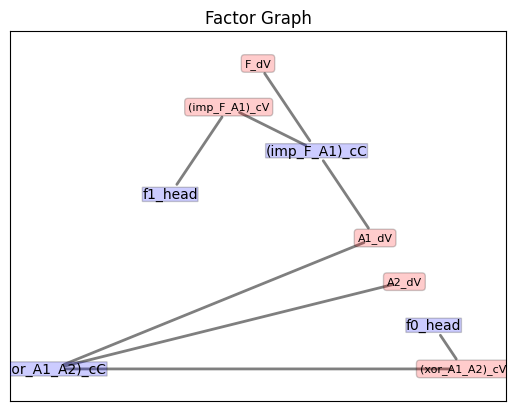

In [5]:
f0_basisDecomposition = ftc.create_formula_computation_cores(
      ["xor", "A1", "A2"]
    )
f1_basisDecomposition = ftc.create_formula_computation_cores(
      ["imp", "F", "A1"]
    )
cores_two = {
    **f0_basisDecomposition, **f1_basisDecomposition,
    "f0_head" : get_e1("(xor_A1_A2)_cV"),
    "f1_head" : get_e1("(imp_F_A1)_cV")
}
engine.draw_factor_graph(cores_two)

In [6]:
kb_two = engine.contract(cores_two, openColors=["A1_dV","A2_dV","F_dV"])

In [14]:
kb_two.values


array([[[0., 0.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.]]])

In [15]:
# When F=1
kb_two.values[:,:,1]

array([[0., 0.],
       [1., 0.]])

In [8]:
# When F=0
kb_two.values[:,:,0]

array([[0., 1.],
       [1., 0.]])

## Representation as a single formula

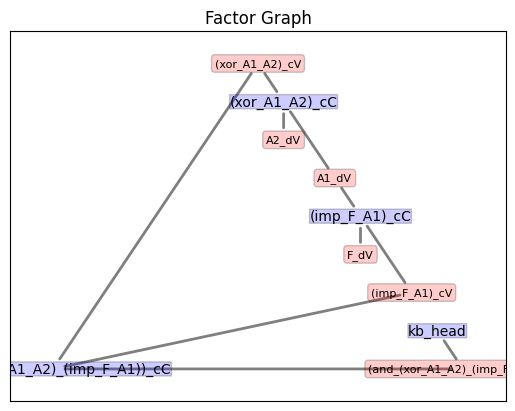

In [9]:
kb_decomposition = ftc.create_formula_computation_cores(
    ["and",
      ["xor", "A1", "A2"],
      ["imp", "F", "A1"]]
    )
cores_single = {**kb_decomposition, "kb_head": get_e1("(and_(xor_A1_A2)_(imp_F_A1))_cV")}
engine.draw_factor_graph(cores_single)

We retrieve the knowledge base by the slice of the kowledge base:

In [16]:
kb_single = engine.contract(cores_single,
                openColors=["A1_dV","A2_dV","F_dV"]
                )

In [17]:
kb_single.values

array([[[0., 0.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.]]])

Check, whether both contracted knowledge bases are the same:

In [12]:
kb_single == kb_two

True